In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
#Load Excel File
df = pd.read_excel(r"D:\Projects\Agriculture Supply Chain Performance Analytics Dashboard\agri_supplychain_cleaned.xlsx")



In [ ]:
#View Data
df.head()

,batch_id,crop_type,region,season,yield_quantity_kg,moisture_content_%,avg_temperature_celsius,transport_delay_hours,equipment_downtime_hours,storage_duration_days,...,supply_chain_stage,resource_utilization_%,climate_risk_level,input_cost_per_kg,final_market_price_per_kg,total_input_cost,total_revenue,estimated_profit,profit_margin_%,spoilage_quantity_kg
0,BATCH00000,Maize,East,Rabi,605.99,13.04,28.30,0.2,2.1,2,...,Farm,85.74,Medium,4.40,6.01,2666.3560,3641.9999,975.6439,0.267887,19.209883
1,BATCH00001,Barley,West,Kharif,561.70,11.23,26.54,1.9,0.2,27,...,Farm,64.03,Medium,9.13,11.36,5128.3210,6380.9120,1252.5910,0.196303,13.705480
2,BATCH00002,Wheat,South,Kharif,568.36,10.58,32.13,0.7,0.4,28,...,Farm,66.16,High,7.93,12.03,4507.0948,6837.3708,2330.2760,0.340815,53.937364
3,BATCH00003,Maize,West,Kharif,363.40,12.64,38.61,0.3,0.4,22,...,Farm,64.38,Low,3.18,13.99,1155.6120,5083.9660,3928.3540,0.772695,4.724200
4,BATCH00004,Maize,West,Rabi,621.19,9.33,36.74,1.6,0.0,7,...,Transit,56.44,High,3.07,7.24,1907.0533,4497.4156,2590.3623,0.575967,15.591869


In [ ]:
#View Column Names
print(df.columns.tolist())

['batch_id', 'crop_type', 'region', 'season', 'yield_quantity_kg', 'moisture_content_%', 'avg_temperature_celsius', 'transport_delay_hours', 'equipment_downtime_hours', 'storage_duration_days', 'quality_grade', 'spoilage_loss_%', 'supply_chain_stage', 'resource_utilization_%', 'climate_risk_level', 'input_cost_per_kg', 'final_market_price_per_kg', 'total_input_cost', 'total_revenue', 'estimated_profit', 'profit_margin_%', 'spoilage_quantity_kg']


In [ ]:
#Remove Extra Spaces from Columns
df.columns = df.columns.str.strip()

In [23]:
print(df.columns.tolist())

['batch_id', 'crop_type', 'region', 'season', 'yield_quantity_kg', 'moisture_content_%', 'avg_temperature_celsius', 'transport_delay_hours', 'equipment_downtime_hours', 'storage_duration_days', 'quality_grade', 'spoilage_loss_%', 'supply_chain_stage', 'resource_utilization_%', 'climate_risk_level', 'input_cost_per_kg', 'final_market_price_per_kg', 'total_input_cost', 'total_revenue', 'estimated_profit', 'profit_margin_%', 'spoilage_quantity_kg']


In [ ]:
#Data Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   batch_id                   2000 non-null   str    
 1   crop_type                  2000 non-null   str    
 2   region                     2000 non-null   str    
 3   season                     2000 non-null   str    
 4   yield_quantity_kg          2000 non-null   float64
 5   moisture_content_%         2000 non-null   float64
 6   avg_temperature_celsius    2000 non-null   float64
 7   transport_delay_hours      2000 non-null   float64
 8   equipment_downtime_hours   2000 non-null   float64
 9   storage_duration_days      2000 non-null   int64  
 10  quality_grade              2000 non-null   str    
 11  spoilage_loss_%            2000 non-null   float64
 12  supply_chain_stage         2000 non-null   str    
 13  resource_utilization_%     2000 non-null   float64
 14  cli

In [ ]:
#Statistical Summary
df.describe()

,yield_quantity_kg,moisture_content_%,avg_temperature_celsius,transport_delay_hours,equipment_downtime_hours,storage_duration_days,spoilage_loss_%,resource_utilization_%,input_cost_per_kg,final_market_price_per_kg,total_input_cost,total_revenue,estimated_profit,profit_margin_%,spoilage_quantity_kg
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,497.630965,12.936025,29.801575,1.989800,1.012500,14.882500,5.190520,74.968255,6.401855,9.967905,3179.124792,4954.803807,1775.679015,0.293623,25.848406
std,101.038343,2.888011,5.658127,1.944255,1.046394,8.198982,2.714734,14.451486,2.003424,2.860701,1188.525287,1758.575211,1838.686239,0.328728,14.848278
min,199.240000,8.000000,20.000000,0.000000,0.000000,1.000000,0.500000,50.060000,3.000000,5.000000,871.032400,1259.196800,-2524.513400,-0.937500,1.468443
25%,428.112500,10.417500,25.047500,0.600000,0.300000,8.000000,2.810000,62.342500,4.650000,7.570000,2231.841000,3571.062375,460.223725,0.123381,13.534658
50%,496.705000,12.870000,29.750000,1.400000,0.700000,15.000000,5.205000,74.460000,6.400000,9.970000,3041.179500,4754.279700,1712.365650,0.364827,24.240607
75%,563.495000,15.452500,34.517500,2.800000,1.400000,22.000000,7.465000,87.712500,8.062500,12.490000,4017.145950,6186.045575,3078.528600,0.541367,36.865950
max,892.620000,17.990000,39.970000,16.100000,6.800000,29.000000,9.990000,99.980000,10.000000,15.000000,6836.992500,10921.440000,7791.358800,0.787551,73.953776


In [26]:
#Check Missing Values
df.isnull().sum()

batch_id                     0
crop_type                    0
region                       0
season                       0
yield_quantity_kg            0
moisture_content_%           0
avg_temperature_celsius      0
transport_delay_hours        0
equipment_downtime_hours     0
storage_duration_days        0
quality_grade                0
spoilage_loss_%              0
supply_chain_stage           0
resource_utilization_%       0
climate_risk_level           0
input_cost_per_kg            0
final_market_price_per_kg    0
total_input_cost             0
total_revenue                0
estimated_profit             0
profit_margin_%              0
spoilage_quantity_kg         0
dtype: int64

In [27]:
#Check Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [43]:
pd.set_option("display.float_format", "{:,.2f}".format)

In [28]:
#Total Yield by Crop
df.groupby("crop_type")["yield_quantity_kg"].sum()

crop_type
Barley    243305.48
Maize     244868.85
Rice      245632.18
Wheat     261455.42
Name: yield_quantity_kg, dtype: float64

In [44]:
#Total Revenue by Crop
df.groupby("crop_type")["total_revenue"].sum()

crop_type
Barley   2,378,104.42
Maize    2,461,321.62
Rice     2,456,678.38
Wheat    2,613,503.20
Name: total_revenue, dtype: float64

In [30]:
#Average Profit Margin by Crop
df.groupby("crop_type")["profit_margin_%"].mean()

crop_type
Barley    0.292151
Maize     0.308057
Rice      0.307881
Wheat     0.268111
Name: profit_margin_%, dtype: float64

In [45]:
#Revenue by Region
df.groupby("region")["total_revenue"].sum()

region
East    2,298,554.23
North   2,602,571.57
South   2,469,554.31
West    2,538,927.50
Name: total_revenue, dtype: float64

In [32]:
#Profit by Region
df.groupby("region")["estimated_profit"].sum()

region
East     829661.9546
North    927017.8989
South    866036.4545
West     928641.7227
Name: estimated_profit, dtype: float64

In [33]:
#Transport Delay by Region
df.groupby("region")["transport_delay_hours"].mean()

region
East     1.995279
North    2.069863
South    1.747287
West     2.150888
Name: transport_delay_hours, dtype: float64

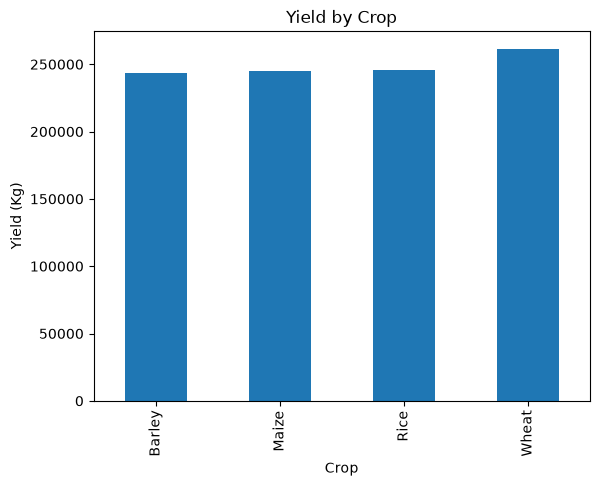

In [34]:
#Yield by Crop (Bar Chart)
yield_data = df.groupby("crop_type")["yield_quantity_kg"].sum()

yield_data.plot(kind="bar")

plt.title("Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Kg)")
plt.show()

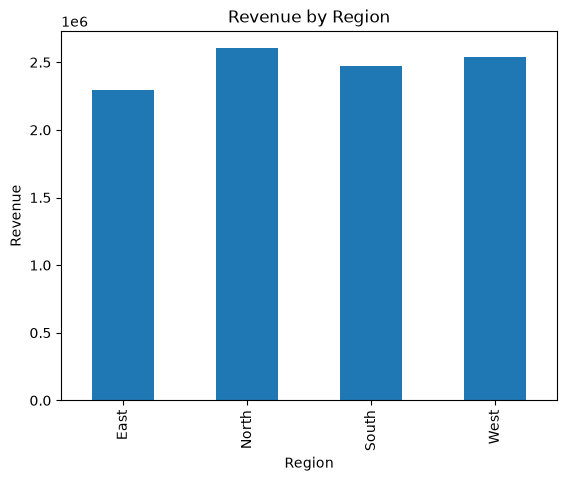

In [35]:
#Revenue by Region
revenue = df.groupby("region")["total_revenue"].sum()

revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

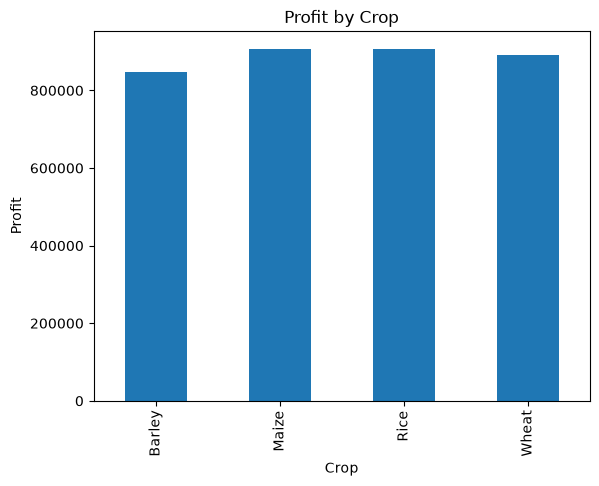

In [36]:
#Profit by Crop
profit = df.groupby("crop_type")["estimated_profit"].sum()

profit.plot(kind="bar")

plt.title("Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Profit")
plt.show()

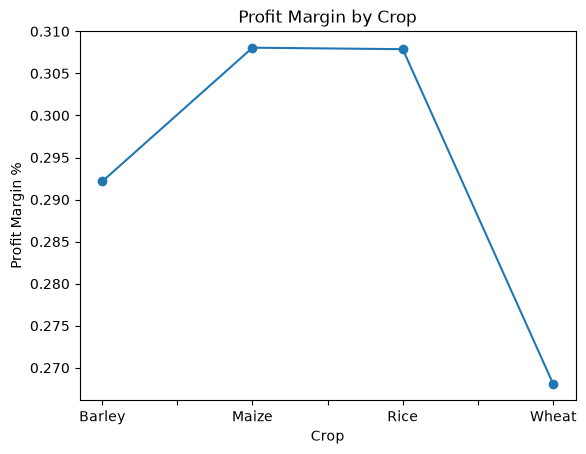

In [37]:
#Profit Margin Line Chart
margin = df.groupby("crop_type")["profit_margin_%"].mean()

margin.plot(kind="line", marker="o")

plt.title("Profit Margin by Crop")
plt.xlabel("Crop")
plt.ylabel("Profit Margin %")
plt.show()

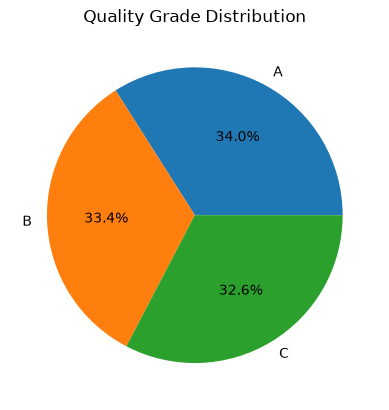

In [38]:
#Quality Grade Pie Chart
quality = df["quality_grade"].value_counts()

plt.pie(
    quality,
    labels=quality.index,
    autopct="%1.1f%%"
)

plt.title("Quality Grade Distribution")
plt.show()

In [39]:
#Most Profitable Crop
df.groupby("crop_type")["estimated_profit"].sum().sort_values(ascending=False)

crop_type
Maize     907182.6258
Rice      905510.3296
Wheat     890258.3792
Barley    848406.6961
Name: estimated_profit, dtype: float64

In [46]:
#Highest Revenue Region
df.groupby("region")["total_revenue"].sum().sort_values(ascending=False)

region
North   2,602,571.57
West    2,538,927.50
South   2,469,554.31
East    2,298,554.23
Name: total_revenue, dtype: float64

In [41]:
#Highest Spoilage Stage
df.groupby("supply_chain_stage")["spoilage_quantity_kg"].sum().sort_values(ascending=False)

supply_chain_stage
Transit      18078.902137
Farm         17437.646156
Warehouse    16180.264200
Name: spoilage_quantity_kg, dtype: float64

In [42]:
print("Python EDA Completed Successfully")

Python EDA Completed Successfully
